In [1]:
import xarray as xr

In [2]:
ap6_folder_future = "/hkfs/work/workspace/scratch/ou4895-for_lukas/SSP585/ap6"
ap8_folder_future = "/hkfs/work/workspace/scratch/ou4895-for_lukas/SSP585/ap8"
apk_folder_future = "/hkfs/work/workspace/scratch/ou4895-for_lukas/SSP585/apk"
apc_folder_future = "/hkfs/work/workspace/scratch/ou4895-for_lukas/SSP585/apc"
ap6_folder_hist = "/hkfs/work/workspace/scratch/ou4895-for_lukas/Hist/ap6"
ap8_folder_hist = "/hkfs/work/workspace/scratch/ou4895-for_lukas/Hist/ap8"
apk_folder_hist = "/hkfs/work/workspace/scratch/ou4895-for_lukas/Hist/apk"
apc_folder_hist = "/hkfs/work/workspace/scratch/ou4895-for_lukas/Hist/apc"
out = '/hkfs/work/workspace/scratch/xo8179-ukesm/not_regridded/'

In [3]:
def load_x_files_from_folder(folder:str, first=0, last=-1):
    import os
    import glob

    # Get all .nc files in the folder
    files = sorted(glob.glob(os.path.join(folder, "*.nc")))
    print(f'Found {len(files)} in specified folder.')

    # Select the last 5 files
    if first < 0 or last < 0:
        print(f'Attempting to load {len(files) - first} files...')
        selected_files = files[first:]
    else:
        print(f'Attempting to load {last - first} files...')
        selected_files = files[first:last]

    # Load them as a combined dataset
    ds = xr.open_mfdataset(selected_files,
                           parallel=True, # Enable parallel reads
                           chunks='auto', # Let dask decide chunking
                           combine='by_coords')

    return ds

In [ ]:
ds = load_x_files_from_folder(ap8_folder_hist, 100,101)

for i in range(1296):
    ds = load_x_files_from_folder(ap8_folder_hist, i,i+1)
    if not (list(ds.data_vars)) == ['precip']:
        print(list(ds.data_vars))

In [5]:
ds = xr.open_dataset('/hkfs/work/workspace/scratch/xo8179-ukesm/not_regridded/SSP585/apc/temp.zarr')

In [6]:
print(ds)

<xarray.Dataset> Size: 83GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, t_1: 124200)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 994kB 2015-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    temp       (t_1, p_2, latitude, longitude) float32 83GB ...
Attributes:
    history:  Sun Sep  7 21:59:19 BST 2025 - CONVSH V1.94 03-May-2018


In [6]:
# ds['temp'].to_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/not_regridded/Hist/ap8/temp.zarr', mode="w")
# ds['precip'].to_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/not_regridded/Hist/ap8/precip.zarr', mode="w")

# Loading apc

In [ ]:
import os
import glob
import xarray as xr

def save_subset(ds, vars_to_select, i, append_dim, name):
    ds_selected = None
    rename_dims = {}
    try:
        ds_selected = ds[vars_to_select]
    except Exception:
        return False
    if ds_selected:
        if i == 0:
            ds_selected.to_zarr(output_path+name+'.zarr', mode="w")
        else:
            ds_selected.to_zarr(output_path+name+'.zarr', mode="a", append_dim=append_dim)
    return True

# Input folder
folder = apc_folder_future
# Output path
output_path = '/hkfs/work/workspace/scratch/xo8179-ukesm/not_regridded/SSP585/apc/'

# Get all NetCDF files, sorted
files = sorted(glob.glob(os.path.join(folder, "*.nc")))
print(f"Found {len(files)} files")

# Loop through files and append to Zarr store
for i, f in enumerate(files):
    if i < 151:
        continue
    print(f"[{i+1}/{len(files)}] Processing")

    ds = xr.open_dataset(f, chunks={})   # open one file only
    expected_vars = ['wind','ht_1','p_1','u','v','dz_dt','temp','q','psag','rvor','rvor_1','rvor_2','rvor_3']
    unexpected_vars=[]
    for var in ds.data_vars:
        if not var in expected_vars:
            unexpected_vars.append(var)
    
    not_found = []
    filename = f.split('/')[-1]
    
    if not save_subset(ds, ['wind'], i, 't', 'wind'):
        not_found.append('wind')

    if not save_subset(ds, ['u', 'v'], i, 't_1', 'uv'):
        not_found.append('uv')
    
    if not save_subset(ds, ['rvor', 'rvor_1', 'rvor_2', 'rvor_3'], i, 't_1', 'rvor'):
        not_found.append('rvor')

    if not save_subset(ds, ['q'], i, 't_1', 'q'):
        not_found.append('q')

    if not save_subset(ds, ['temp'], i, 't_1', 'temp'):
        not_found.append('temp')

    if not save_subset(ds, ['psag'], i, 't_1', 'psag'):
        not_found.append('psag')

    if not save_subset(ds, ['dz_dt'], i, 't_1', 'dz_dt'):
        not_found.append('dz_dt')

    if not save_subset(ds, ['p_1'], i, 't_1', 'p_1'):
        not_found.append('p_1')

    if not save_subset(ds, ['ht_1'], i, 't_1', 'ht_1'):
        not_found.append('ht_1')
        
    if len(not_found) > 0:
        print(f'Did not find {str(not_found)} in {filename}')
    if len(unexpected_vars) > 0:
        print(f'Found unexpected vars {str(unexpected_vars)} in {filename}')
    ds.close()

print("✅ All files merged into Zarr:", output_path)

# Loading apk

In [ ]:
import os
import glob
import xarray as xr

# Input folder
folder = apk_folder_future
# Output path
output_path = '/hkfs/work/workspace/scratch/xo8179-ukesm/not_regridded/SSP585/apk/'

# Get all NetCDF files, sorted
files = sorted(glob.glob(os.path.join(folder, "*.nc")))
print(f"Found {len(files)} files")

# Loop through files and append to Zarr store
for i, f in enumerate(files):
    print(f"[{i+1}/{len(files)}] Processing")

    ds = xr.open_dataset(f, chunks={})   # open one file only
    expected_vars = ['u', 'v', 'precip']
    unexpected_vars=[]
    for var in ds.data_vars:
        if not var in expected_vars:
            unexpected_vars.append(var)
    
    not_found = []
    filename = f.split('/')[-1]
    
    ds_selected = None
    rename_dims = {}
    try:
        vars = ['precip']
        ds_selected = ds[vars]
    except Exception:
        not_found.append('precip')
    if ds_selected:
        if "longitude" in ds_selected.dims:
            rename_dims["longitude"] = "longitude_1"
            ds_selected = ds_selected.rename(rename_dims)
        if i == 0:
            ds_selected.to_zarr(output_path+'precip.zarr', mode="w")
        else:
            ds_selected.to_zarr(output_path+'precip.zarr', mode="a", append_dim="t")
    
    ds_selected = None
    rename_dims = {}
    try:
        vars = ['u', 'v']
        ds_selected = ds[vars]
    except Exception:
        not_found.append('uv')
    if ds_selected:
        if i == 0:
            ds_selected.to_zarr(output_path+'uv.zarr', mode="w")
        else:
            ds_selected.to_zarr(output_path+'uv.zarr', mode="a", append_dim="t")
    
        
    if len(not_found) > 0:
        print(f'Did not find {str(not_found)} in {filename}')
    if len(unexpected_vars) > 0:
        print(f'Found unexpected vars {str(unexpected_vars)} in {filename}')
    ds.close()

print("✅ All files merged into Zarr:", output_path)

# Loading ap6

In [ ]:
import os
import glob
import xarray as xr

# Input folder
folder = ap6_folder_future
# Output path
output_path = '/hkfs/work/workspace/scratch/xo8179-ukesm/not_regridded/SSP585/ap6/'

# Get all NetCDF files, sorted
files = sorted(glob.glob(os.path.join(folder, "*.nc")))
print(f"Found {len(files)} files")

# Loop through files and append to Zarr store
for i, f in enumerate(files):
    if i<623:
        continue
    print(f"[{i+1}/{len(files)}] Processing")

    ds = xr.open_dataset(f, chunks={})   # open one file only
    expected_vars = ['temp', 'temp_1', 'temp_2', 'precip', 'u', 'v','ht', 'ht_1', 'ht_2', 'ht_3', 'ht_4', 'ht_5']
    unexpected_vars=[]
    for var in ds.data_vars:
        if not var in expected_vars:
            unexpected_vars.append(var)
    
    not_found = []
    filename = f.split('/')[-1]
    
    ds_selected = None
    rename_dims = {}
    try:
        vars = ['temp', 'temp_1', 'temp_2']
        ds_selected = ds[vars]
    except Exception:
        not_found.append('temps')
    if ds_selected:
        if "longitude" in ds_selected.dims:
            rename_dims["longitude"] = "longitude_1"
            ds_selected = ds_selected.rename(rename_dims)
        if i == 0:
            ds_selected.to_zarr(output_path+'temps.zarr', mode="w")
        else:
            ds_selected.to_zarr(output_path+'temps.zarr', mode="a", append_dim="t")
    
    ds_selected = None
    rename_dims = {}
    try:
        vars = ['precip']
        ds_selected = ds[vars]
    except Exception:
        not_found.append('precip')
    if ds_selected:
        if "longitude" in ds_selected.dims:
            rename_dims["longitude"] = "longitude_1"
            ds_selected = ds_selected.rename(rename_dims)
        if i == 0:
            ds_selected.to_zarr(output_path+'precip.zarr', mode="w")
        else:
            ds_selected.to_zarr(output_path+'precip.zarr', mode="a", append_dim="t")
    

    ds_selected = None
    rename_dims = {}
    try:
        vars = ['u', 'v']
        ds_selected = ds[vars]
    except Exception:
        not_found.append('uv')
    if ds_selected:
        if i == 0:
            ds_selected.to_zarr(output_path+'uv.zarr', mode="w")
        else:
            ds_selected.to_zarr(output_path+'uv.zarr', mode="a", append_dim="t")
    
        
    if "ht" in ds.data_vars:
        rename_vars = {
            "ht": "ht_1",
            "ht_1": "ht_2",
            "ht_2": "ht_3",
            "ht_3": "ht_4",
            "ht_4": "ht_5",
        }
        ds = ds.rename(rename_vars)

        rename_dims = {}
        if "longitude" in ds.dims:
            rename_dims["longitude"] = "longitude_1"
        if "longitude_1" in ds.dims:
            rename_dims["longitude_1"] = "longitude_2"
        if rename_dims:
            ds = ds.rename(rename_dims)

    ds_selected = None
    try:
        vars = ['ht_1', 'ht_2', 'ht_3', 'ht_4', 'ht_5']
        ds_selected = ds[vars]
    except Exception:
        not_found.append('hts')
    if ds_selected:
        if i == 0:
            ds_selected.to_zarr(output_path+'hts.zarr', mode="w")
        else:
            ds_selected.to_zarr(output_path+'hts.zarr', mode="a", append_dim="t")
    

    if len(not_found) > 0:
        print(f'Did not find {str(not_found)} in {filename}')
    if len(unexpected_vars) > 0:
        print(f'Found unexpected vars {str(unexpected_vars)} in {filename}')
    ds.close()

print("✅ All files merged into Zarr:", output_path)

# Missing values

## apk
historical:
- No u and v in 1984

future:
- No u and v in 2099

## ap6
historical:
- From 1980: Only ht variables (except 1984)
- In 1984: No ht variables (only temp and precip)
- 1991 is fine

# Done
- ap8 (hist, future)
- apk (hist, future)
- ap6 (hist, future)
- apc (hist, future)


# Select the useful data

# Height

### Hist

In [3]:
levels = [925, 850, 700, 500, 300, 200]

In [ ]:

ds = xr.open_dataset(out+'Hist/ap6/hts.zarr')
print(ds)

In [ ]:
ds_selected = ds['ht_3']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/pl_height.zarr')

### Future

In [31]:
ds = xr.open_dataset(out+'SSP585/ap6/hts.zarr')
print(ds)

<xarray.Dataset> Size: 106GB
Dimensions:      (t: 30960, p: 3, latitude: 144, longitude_1: 192, p_1: 2,
                  p_2: 18, p_3: 19, longitude_2: 1, p_4: 8)
Coordinates:
  * latitude     (latitude) float32 576B -89.38 -88.12 -86.88 ... 88.12 89.38
  * longitude_1  (longitude_1) float32 768B 0.9375 2.812 4.688 ... 357.2 359.1
  * longitude_2  (longitude_2) float32 4B 357.2
  * p            (p) float32 12B 10.0 100.0 1e+03
  * p_1          (p_1) float32 8B 500.0 1e+03
  * p_2          (p_2) float32 72B 925.0 850.0 700.0 600.0 ... 20.0 10.0 5.0 1.0
  * p_3          (p_3) float32 76B 1e+03 925.0 850.0 700.0 ... 20.0 10.0 5.0 1.0
  * p_4          (p_4) float32 32B 1e+03 850.0 700.0 500.0 250.0 100.0 50.0 10.0
  * t            (t) object 248kB 2015-01-01 12:00:00 ... 2100-12-30 12:00:00
Data variables:
    ht_1         (t, p, latitude, longitude_1) float32 10GB ...
    ht_2         (t, p_1, latitude, longitude_1) float32 7GB ...
    ht_3         (t, p_2, latitude, longitude_1) float32

In [ ]:
ds_selected = ds['ht_3']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/pl_height.zarr', mode='a', append_dim="t")

In [ ]:
ds = xr.open_dataset(out + 'final/pl_height.zarr')
print(ds)

<xarray.Dataset> Size: 86GB
Dimensions:      (t: 43200, p_2: 18, latitude: 144, longitude_1: 192)
Coordinates:
  * latitude     (latitude) float32 576B -89.38 -88.12 -86.88 ... 88.12 89.38
  * longitude_1  (longitude_1) float32 768B 0.9375 2.812 4.688 ... 357.2 359.1
  * p_2          (p_2) float32 72B 925.0 850.0 700.0 600.0 ... 20.0 10.0 5.0 1.0
  * t            (t) object 346kB 1979-01-01 12:00:00 ... 2100-12-30 12:00:00
Data variables:
    ht_3         (t, p_2, latitude, longitude_1) float32 86GB ...


# U an V

### Hist

In [8]:
ds = xr.open_dataset(out+'Hist/apc/uv.zarr')
print(ds)

<xarray.Dataset> Size: 69GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, t_1: 51840)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 415kB 1979-01-01 06:00:00 ... 2015-01-01 00:00:00
Data variables:
    u          (t_1, p_2, latitude, longitude) float32 35GB ...
    v          (t_1, p_2, latitude, longitude) float32 35GB ...
Attributes:
    history:  Sun Jul 27 16:49:11 BST 2025 - CONVSH V1.94 03-May-2018


In [9]:
# new_time_chunk = 128
# ds_rechunked = ds.chunk({"t_1": new_time_chunk, 'longitude':-1, 'latitude':-1})

In [10]:
ds_selected = ds['u']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/u.zarr', mode='w')

In [11]:
ds_selected = ds['v']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/v.zarr', mode='w')

### Future

In [12]:
ds = xr.open_dataset(out+'SSP585/apc/uv.zarr')
print(ds)

<xarray.Dataset> Size: 166GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, t_1: 124200)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 994kB 2015-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    u          (t_1, p_2, latitude, longitude) float32 83GB ...
    v          (t_1, p_2, latitude, longitude) float32 83GB ...
Attributes:
    history:  Sun Sep  7 21:59:19 BST 2025 - CONVSH V1.94 03-May-2018


In [13]:
ds_selected = ds['u']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/u.zarr', mode='a', append_dim="t_1")

In [14]:
ds_selected = ds['v']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/v.zarr', mode='a', append_dim="t_1")

# Temp

### Hist

In [4]:
ds = xr.open_dataset(out+'Hist/apc/temp.zarr')
print(ds)

<xarray.Dataset> Size: 35GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, t_1: 51840)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 415kB 1979-01-01 06:00:00 ... 2015-01-01 00:00:00
Data variables:
    temp       (t_1, p_2, latitude, longitude) float32 35GB ...
Attributes:
    history:  Sun Jul 27 16:49:11 BST 2025 - CONVSH V1.94 03-May-2018


In [5]:
ds_selected = ds['temp']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/temp.zarr', mode='w')

### Future

In [7]:
ds = xr.open_dataset(out+'SSP585/apc/temp.zarr')
print(ds)

<xarray.Dataset> Size: 83GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, t_1: 124200)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 994kB 2015-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    temp       (t_1, p_2, latitude, longitude) float32 83GB ...
Attributes:
    history:  Sun Sep  7 21:59:19 BST 2025 - CONVSH V1.94 03-May-2018


In [8]:
ds_selected = ds['temp']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/temp.zarr', mode='a', append_dim="t_1")

# Specific Humidity (q)

### Hist

In [9]:
ds = xr.open_dataset(out+'Hist/apc/q.zarr')
print(ds)

<xarray.Dataset> Size: 35GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, t_1: 51840)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 415kB 1979-01-01 06:00:00 ... 2015-01-01 00:00:00
Data variables:
    q          (t_1, p_2, latitude, longitude) float32 35GB ...
Attributes:
    history:  Sun Jul 27 16:49:11 BST 2025 - CONVSH V1.94 03-May-2018


In [10]:
ds_selected = ds['q']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/q.zarr', mode='w')

### Future

In [11]:
ds = xr.open_dataset(out+'SSP585/apc/q.zarr')
print(ds)

<xarray.Dataset> Size: 83GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, t_1: 124200)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 994kB 2015-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    q          (t_1, p_2, latitude, longitude) float32 83GB ...
Attributes:
    history:  Sun Sep  7 21:59:19 BST 2025 - CONVSH V1.94 03-May-2018


In [12]:
ds_selected = ds['q']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/q.zarr', mode='a', append_dim="t_1")

# Relative Vorticity (Rvor)

### Hist

In [13]:
ds = xr.open_dataset(out+'Hist/apc/rvor.zarr')
print(ds)

<xarray.Dataset> Size: 81GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, p_3: 1, t_1: 51840)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * p_3        (p_3) float32 4B -1.0
  * t_1        (t_1) object 415kB 1979-01-01 06:00:00 ... 2015-01-01 00:00:00
Data variables:
    rvor       (t_1, p_3, latitude, longitude) float32 6GB ...
    rvor_1     (t_1, p_3, latitude, longitude) float32 6GB ...
    rvor_2     (t_1, p_2, latitude, longitude) float32 35GB ...
    rvor_3     (t_1, p_2, latitude, longitude) float32 35GB ...
Attributes:
    history:  Sun Jul 27 16:49:11 BST 2025 - CONVSH V1.94 03-May-2018


In [14]:
ds_selected = ds['rvor_2']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/rvor_2.zarr', mode='w')

### Future

In [15]:
ds = xr.open_dataset(out+'SSP585/apc/rvor.zarr')
print(ds)

<xarray.Dataset> Size: 194GB
Dimensions:    (latitude: 145, longitude: 192, p_2: 6, p_3: 1, t_1: 124200)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * p_3        (p_3) float32 4B -1.0
  * t_1        (t_1) object 994kB 2015-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    rvor       (t_1, p_3, latitude, longitude) float32 14GB ...
    rvor_1     (t_1, p_3, latitude, longitude) float32 14GB ...
    rvor_2     (t_1, p_2, latitude, longitude) float32 83GB ...
    rvor_3     (t_1, p_2, latitude, longitude) float32 83GB ...
Attributes:
    history:  Sun Sep  7 21:59:19 BST 2025 - CONVSH V1.94 03-May-2018


In [16]:
ds_selected = ds['rvor_2']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/rvor_2.zarr', mode='a', append_dim="t_1")

# dz_dt

### Hist

In [4]:
ds = xr.open_dataset(out+'Hist/apc/dz_dt.zarr')
print(ds)

<xarray.Dataset> Size: 35GB
Dimensions:    (t_1: 51840, p_2: 6, latitude: 145, longitude: 192)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 415kB 1979-01-01 06:00:00 ... 2015-01-01 00:00:00
Data variables:
    dz_dt      (t_1, p_2, latitude, longitude) float32 35GB ...
Attributes:
    history:  Sun Jul 27 16:49:11 BST 2025 - CONVSH V1.94 03-May-2018


In [5]:
ds_selected = ds['dz_dt']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/dz_dt.zarr', mode='w')

### Future

In [6]:
ds = xr.open_dataset(out+'SSP585/apc/dz_dt.zarr')
print(ds)

<xarray.Dataset> Size: 83GB
Dimensions:    (t_1: 124200, p_2: 6, latitude: 145, longitude: 192)
Coordinates:
  * latitude   (latitude) float32 580B -90.0 -88.75 -87.5 ... 87.5 88.75 90.0
  * longitude  (longitude) float32 768B 0.0 1.875 3.75 ... 354.4 356.2 358.1
  * p_2        (p_2) float32 24B 925.0 850.0 700.0 500.0 300.0 200.0
  * t_1        (t_1) object 994kB 2015-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    dz_dt      (t_1, p_2, latitude, longitude) float32 83GB ...
Attributes:
    history:  Sun Sep  7 21:59:19 BST 2025 - CONVSH V1.94 03-May-2018


In [7]:
ds_selected = ds['dz_dt']
ds_selected = ds_selected.sel(p_2=ds_selected.p_2.isin(levels))
ds_selected.to_zarr(out + 'final/dz_dt.zarr', mode='a', append_dim="t_1")

# Geopotential Height

### Hist

In [17]:
ds = xr.open_dataset(out+'Hist/apc/ht_1.zarr')
print(ds)

<xarray.Dataset> Size: 6GB
Dimensions:      (t_1: 51840, p: 1, latitude_1: 144, longitude_1: 192)
Coordinates:
  * latitude_1   (latitude_1) float32 576B -89.38 -88.12 -86.88 ... 88.12 89.38
  * longitude_1  (longitude_1) float32 768B 0.9375 2.812 4.688 ... 357.2 359.1
  * p            (p) float32 4B 500.0
  * t_1          (t_1) object 415kB 1979-01-01 06:00:00 ... 2015-01-01 00:00:00
Data variables:
    ht_1         (t_1, p, latitude_1, longitude_1) float32 6GB ...
Attributes:
    history:  Sun Jul 27 16:49:11 BST 2025 - CONVSH V1.94 03-May-2018


In [18]:
ds_selected = ds['ht_1']
ds_selected.to_zarr(out + 'final/ht_1.zarr', mode='w')

### Future

In [19]:
ds = xr.open_dataset(out+'SSP585/apc/ht_1.zarr')
print(ds)

<xarray.Dataset> Size: 14GB
Dimensions:      (t_1: 123840, p: 1, latitude_1: 144, longitude_1: 192)
Coordinates:
  * latitude_1   (latitude_1) float32 576B -89.38 -88.12 -86.88 ... 88.12 89.38
  * longitude_1  (longitude_1) float32 768B 0.9375 2.812 4.688 ... 357.2 359.1
  * p            (p) float32 4B 500.0
  * t_1          (t_1) object 991kB 2015-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    ht_1         (t_1, p, latitude_1, longitude_1) float32 14GB ...
Attributes:
    history:  Sun Sep  7 21:59:19 BST 2025 - CONVSH V1.94 03-May-2018


In [20]:
ds_selected = ds['ht_1']
ds_selected.to_zarr(out + 'final/ht_1.zarr', mode='a', append_dim="t_1")

# Surface Level Pressure (SLP)

### Hist

In [22]:
ds = xr.open_dataset(out+'Hist/apc/p_1.zarr')
print(ds)

<xarray.Dataset> Size: 6GB
Dimensions:      (latitude_1: 144, longitude_1: 192, msl: 1, t_1: 51840)
Coordinates:
  * latitude_1   (latitude_1) float32 576B -89.38 -88.12 -86.88 ... 88.12 89.38
  * longitude_1  (longitude_1) float32 768B 0.9375 2.812 4.688 ... 357.2 359.1
  * msl          (msl) float32 4B 0.0
  * t_1          (t_1) object 415kB 1979-01-01 06:00:00 ... 2015-01-01 00:00:00
Data variables:
    p_1          (t_1, msl, latitude_1, longitude_1) float32 6GB ...
Attributes:
    history:  Sun Jul 27 16:49:11 BST 2025 - CONVSH V1.94 03-May-2018


In [23]:
ds_selected = ds['p_1']
ds_selected.to_zarr(out + 'final/p_1.zarr', mode='w')

### Future

In [24]:
ds = xr.open_dataset(out+'SSP585/apc/p_1.zarr')
print(ds)

<xarray.Dataset> Size: 14GB
Dimensions:      (latitude_1: 144, longitude_1: 192, msl: 1, t_1: 123840)
Coordinates:
  * latitude_1   (latitude_1) float32 576B -89.38 -88.12 -86.88 ... 88.12 89.38
  * longitude_1  (longitude_1) float32 768B 0.9375 2.812 4.688 ... 357.2 359.1
  * msl          (msl) float32 4B 0.0
  * t_1          (t_1) object 991kB 2015-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    p_1          (t_1, msl, latitude_1, longitude_1) float32 14GB ...
Attributes:
    history:  Sun Sep  7 21:59:19 BST 2025 - CONVSH V1.94 03-May-2018


In [25]:
ds_selected = ds['p_1']
ds_selected.to_zarr(out + 'final/p_1.zarr', mode='a', append_dim="t_1")

In [3]:
final_folder = '/hkfs/work/workspace/scratch/xo8179-ukesm/regridded/'
ds = xr.open_dataset(final_folder + 'u.zarr')
print(ds)

<xarray.Dataset> Size: 35GB
Dimensions:    (latitude: 64, level: 6, longitude: 128, time: 176040)
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * level      (level) float32 24B 200.0 300.0 500.0 700.0 850.0 925.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) object 1MB 1979-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    u          (time, level, longitude, latitude) float32 35GB ...


In [5]:
last_values = ds.isel(level=-1, time=-1)
print(last_values)

<xarray.Dataset> Size: 34kB
Dimensions:    (latitude: 64, longitude: 128)
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
    level      float32 4B 925.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
    time       object 8B 2101-01-01 00:00:00
Data variables:
    u          (longitude, latitude) float32 33kB ...


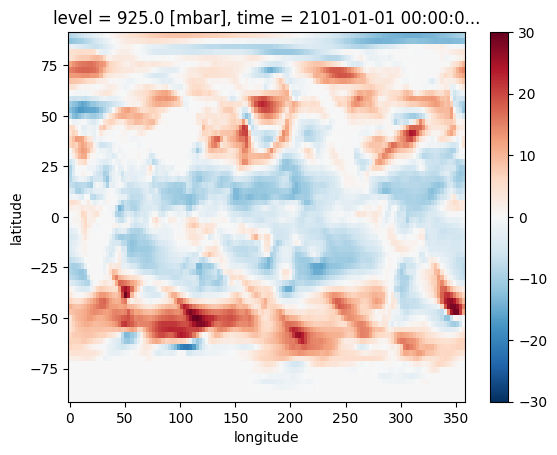

In [11]:
from matplotlib import pyplot as plt
last_values.to_dataarray().T.plot()

### Select training and test data

In [33]:
load_from = '/hkfs/work/workspace/scratch/xo8179-ukesm/regridded/'

In [34]:
u = xr.open_dataset(load_from + 'u.zarr')

In [35]:
v = xr.open_dataset(load_from + 'v.zarr')

In [36]:
temp = xr.open_dataset(load_from + 'temp.zarr')

In [37]:
q = xr.open_dataset(load_from + 'q.zarr')

In [38]:
rvor = xr.open_dataset(load_from + 'rvor_2.zarr')

In [39]:
geopot_500 = xr.open_dataset(load_from + 'ht_1.zarr')

In [40]:
slp = xr.open_dataset(load_from + 'p_1.zarr')

In [41]:
dz_dt = xr.open_dataset(load_from + 'dz_dt.zarr')

In [42]:
print(u)

<xarray.Dataset> Size: 35GB
Dimensions:    (latitude: 64, level: 6, longitude: 128, time: 176040)
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * level      (level) float32 24B 200.0 300.0 500.0 700.0 850.0 925.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) object 1MB 1979-01-01 06:00:00 ... 2101-01-01 00:00:00
Data variables:
    u          (time, level, longitude, latitude) float32 35GB ...


In [43]:
dsera5 = xr.open_dataset('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_era5_1980_2022_6h-128x64_equiangular_with_poles_conservative/fields.zarr')

In [44]:
print(dsera5)

<xarray.Dataset> Size: 167GB
Dimensions:                  (time: 61400, longitude: 128, latitude: 64,
                              level: 13)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
  * time                     (time) datetime64[ns] 491kB 1979-12-23 ... 2021-...
Data variables: (12/13)
    10m_u_component_of_wind  (time, longitude, latitude) float32 2GB ...
    10m_v_component_of_wind  (time, longitude, latitude) float32 2GB ...
    2m_temperature           (time, longitude, latitude) float32 2GB ...
    geopotential             (time, level, longitude, latitude) float32 26GB ...
    geopotential_at_surface  (longitude, latitude) float32 33kB ...
    land_sea_mask            (longitude, latitude) float32 33kB ...
    ...                       ...
    specific_humidity        

In [3]:
### Choose variables here ###
train=True
train_years = (1990, 2019)
future_test_years = (2090, 2100)

In [4]:
import cftime
train_dir = f'/hkfs/work/workspace/scratch/xo8179-ukesm/global_{train_years[0]}_{train_years[1]}_equiangular_wp_conservative/fields.zarr'
future_test_dir = f'/hkfs/work/workspace/scratch/xo8179-ukesm/global_{future_test_years[0]}_{future_test_years[1]}_equiangular_wp_conservative/fields.zarr'
if train:
    slice_start = cftime.Datetime360Day(train_years[0], 1, 1)
    slice_end = cftime.Datetime360Day(train_years[1], 12, 30)
    current_dir = train_dir
else:
    slice_start = cftime.Datetime360Day(future_test_years[0], 1, 1)
    slice_end = cftime.Datetime360Day(future_test_years[1], 12, 30)
    current_dir = future_test_dir

In [47]:
print(train_dir)
print(future_test_dir)

/hkfs/work/workspace/scratch/xo8179-ukesm/global_1990_2019_equiangular_wp_conservative/fields.zarr
/hkfs/work/workspace/scratch/xo8179-ukesm/global_2090_2100_equiangular_wp_conservative/fields.zarr


In [48]:
u_subset = u.sel(time=slice(slice_start, slice_end))
rename_vars = { "u": "u_component_of_wind" }
u_subset = u_subset.rename(rename_vars)
u_subset.to_zarr(current_dir, mode='w')

In [49]:
v_subset = v.sel(time=slice(slice_start, slice_end))
rename_vars = { "v": "v_component_of_wind" }
v_subset = v_subset.rename(rename_vars)
v_subset.to_zarr(current_dir, mode='a')

In [50]:
temp_subset = temp.sel(time=slice(slice_start, slice_end))
rename_vars = { "temp": "temperature" }
temp_subset = temp_subset.rename(rename_vars)
temp_subset.to_zarr(current_dir, mode='a')

In [51]:
q_subset = q.sel(time=slice(slice_start, slice_end))
rename_vars = { "q": "specific_humidity" }
q_subset = q_subset.rename(rename_vars)
q_subset.to_zarr(current_dir, mode='a')

In [52]:
dz_dt_subset = dz_dt.sel(time=slice(slice_start, slice_end))
rename_vars = { "dz_dt": "vertical_velocity" }
dz_dt_subset = dz_dt_subset.rename(rename_vars)
dz_dt_subset.to_zarr(current_dir, mode='a')

In [53]:
rvor_subset = rvor.sel(time=slice(slice_start, slice_end))
rename_vars = { "rvor_2": "relative_vorticity" }
rvor_subset = rvor_subset.rename(rename_vars)
rvor_subset.to_zarr(current_dir, mode='a')

In [54]:
geopot_500_subset = geopot_500.sel(time=slice(slice_start, slice_end))
rename_vars = { "ht_1": "geopotential_500" }
geopot_500_subset = geopot_500_subset.rename(rename_vars)
print(geopot_500_subset)

<xarray.Dataset> Size: 519MB
Dimensions:           (time: 15837, p: 1, longitude: 128, latitude: 64)
Coordinates:
  * latitude          (latitude) float64 512B -90.0 -87.14 -84.29 ... 87.14 90.0
  * longitude         (longitude) float64 1kB 0.0 2.812 5.625 ... 354.4 357.2
  * p                 (p) float32 4B 500.0
  * time              (time) object 127kB 2090-01-01 00:00:00 ... 2100-12-30 ...
Data variables:
    geopotential_500  (time, p, longitude, latitude) float32 519MB ...


In [55]:
g2d = geopot_500_subset['geopotential_500'].squeeze('p', drop=True)
g2d.name = 'geopotential_500'  # rename cleanly

g2d.to_zarr(current_dir, mode='a')

In [56]:
slp_subset = slp.sel(time=slice(slice_start, slice_end))
rename_vars = { "p_1": "mean_sea_level_pressure" }
slp_subset = slp_subset.rename(rename_vars)
print(slp_subset)

<xarray.Dataset> Size: 519MB
Dimensions:                  (latitude: 64, longitude: 128, msl: 1, time: 15837)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
  * msl                      (msl) float32 4B 0.0
  * time                     (time) object 127kB 2090-01-01 00:00:00 ... 2100...
Data variables:
    mean_sea_level_pressure  (time, msl, longitude, latitude) float32 519MB ...


In [57]:
g2d = slp_subset['mean_sea_level_pressure'].squeeze('msl', drop=True)
g2d.name = 'mean_sea_level_pressure'  # rename cleanly

g2d.to_zarr(current_dir, mode='a')

In [58]:
dsera5_subset = dsera5[['geopotential_at_surface', 'land_sea_mask']]

In [59]:
print(dsera5_subset)

<xarray.Dataset> Size: 67kB
Dimensions:                  (longitude: 128, latitude: 64)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
Data variables:
    geopotential_at_surface  (longitude, latitude) float32 33kB ...
    land_sea_mask            (longitude, latitude) float32 33kB ...


In [60]:
dsera5_subset.to_zarr(current_dir, mode='a')

In [5]:
final = xr.open_dataset(current_dir)
print(final)

<xarray.Dataset> Size: 54GB
Dimensions:                  (time: 43197, longitude: 128, latitude: 64,
                              level: 6)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * level                    (level) float32 24B 200.0 300.0 ... 850.0 925.0
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
  * time                     (time) object 346kB 1990-01-01 00:00:00 ... 2019...
Data variables:
    geopotential_500         (time, longitude, latitude) float32 1GB ...
    geopotential_at_surface  (longitude, latitude) float32 33kB ...
    land_sea_mask            (longitude, latitude) float32 33kB ...
    mean_sea_level_pressure  (time, longitude, latitude) float32 1GB ...
    relative_vorticity       (time, level, longitude, latitude) float32 8GB ...
    specific_humidity        (time, level, longitude, latitude) float32 8GB ...
    temperature              (time, level, longitude, latitude) float3

In [8]:

import numpy as np
import pandas as pd
fields_group = final

# Lat-lon
grid_lat_vals = np.array(
    fields_group["latitude"], dtype=np.float32
)  # (num_lat,)
grid_lon_vals = np.array(
    fields_group["longitude"], dtype=np.float32
)  # (num_long,)
num_lat = grid_lat_vals.shape[0]
num_lon = grid_lon_vals.shape[0]

# Construct timestamps
# Time 0 here is 1959-01-01, 00:00
print("Constructing timestamps")
time_vals = fields_group.coords["time"].values

# Handle CFTime vs datetime64 calendars
if np.issubdtype(time_vals.dtype, np.datetime64):
    # Regular datetime64 (ERA5-style)
    timestamps = time_vals.astype("datetime64[s]")
    seconds_since_epoch = timestamps.astype("int64")
    timestamps_for_graphcast = time_vals.astype("datetime64[ns]")
else:
    # CFTime (360-day or other non-Gregorian calendars)
    timestamps = time_vals  # keep as cftime.Datetime360Day objects
    
    # CFTime → approximate datetime64 (drop calendar info)
    dt_seconds = (time_vals[1] - time_vals[0]).total_seconds()
    freq_hours = int(round(dt_seconds / 3600))
    
    # Create a continuous datetime64 series with same number of steps
    timestamps_for_graphcast = pd.date_range(
        start="1990-01-01 00:00:00",
        periods=len(time_vals),
        freq=f"{freq_hours}H"
    )

    # Convert to numeric seconds manually
    epoch = cftime.Datetime360Day(1959, 1, 1, 0, 0, 0)
    seconds_since_epoch = np.array([
        (t - epoch).total_seconds() for t in timestamps
    ], dtype=np.float64)


Constructing timestamps


/scratch/slurm_tmpdir/job_3568183/ipykernel_4062958/3261686653.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps_for_graphcast = pd.date_range(


In [10]:
print(timestamps_for_graphcast[-1])

2019-07-27 00:00:00
